# Arquitectura de Datos: Vision General y Tipos

**Bloque 6 -- Gobierno del Dato y Estrategia | Sesion 1 de 5**

En esta sesion exploraremos que es la arquitectura de datos, por que resulta esencial antes de hablar de gobierno del dato, y cuales son los principales patrones arquitectonicos que una organizacion puede adoptar. Trabajaremos con un escenario ficticio -- el Hospital General Santa Clara -- que nos permitira anclar cada concepto en decisiones reales sobre datos clinicos, operativos y de investigacion.

Al finalizar la sesion seras capaz de:

- Explicar que es una arquitectura de datos y en que se diferencia de la infraestructura y del gobierno del dato.
- Identificar las cuatro capas fundamentales de cualquier arquitectura de datos.
- Comparar los principales tipos de arquitectura (Data Warehouse, Data Lake, Data Lakehouse, Data Mesh).
- Aplicar el patron de capas Bronze, Silver y Gold a un flujo de datos clinicos.
- Utilizar una matriz de decision para recomendar la arquitectura mas adecuada segun el contexto.

## 1. Que es la arquitectura de datos y por que importa

Imaginemos que vamos a construir un hospital desde cero. Antes de poner un solo ladrillo, necesitamos un plano: donde estaran las urgencias, como se conectan con el laboratorio, por donde fluyen las muestras hasta farmacia, quien tiene acceso al archivo de historiales. Sin ese plano, cada departamento construiria su propia logica, los datos de un paciente estarian dispersos en sistemas que no se hablan entre si, y cualquier intento de analisis global seria un ejercicio de arqueologia.

La **arquitectura de datos** es exactamente ese plano, pero para la informacion de una organizacion. Define:

- **Que datos** se recogen y donde se almacenan.
- **Como fluyen** desde las fuentes hasta los consumidores (analistas, dashboards, modelos de ML).
- **Que reglas** gobiernan su calidad, seguridad y ciclo de vida.
- **Que tecnologias** soportan cada capa del flujo.

Es importante no confundir tres conceptos que a menudo se mezclan:

| Concepto | Que responde | Ejemplo en Santa Clara |
|---|---|---|
| **Arquitectura de datos** | Como se organiza y fluye la información | "Los datos clinicos pasan de HIS a un data lake, se limpian en una capa silver y se sirven a dashboards" |
| **Infraestructura de datos** | Sobre que hardware/software se ejecuta | "Usamos AWS S3 para almacenamiento y Spark para procesamiento" |
| **Gobierno del dato** | Quien es responsable y que politicas aplican | "El Comite de Datos aprueba los estandares de calidad y el DPO supervisa el cumplimiento del RGPD" |

La arquitectura es el plano; la infraestructura es el material de construccion; el gobierno es el reglamento del edificio. En este bloque empezamos por el plano para que todo lo que venga después -- gobierno, calidad, privacidad -- tenga una estructura sobre la que asentarse.

## 2. Componentes de una arquitectura de datos

Cualquier arquitectura de datos, independientemente de su complejidad, se puede descomponer en cuatro capas lógicas:

1. **Fuentes (Ingestion)**: Los sistemas donde se originan los datos. En un hospital pueden ser el HIS (sistema de informacion hospitalaria), el LIS (laboratorio), el sistema de farmacia, dispositivos IoT (monitores de constantes, wearables), o fuentes externas como registros del sistema nacional de salud.

2. **Almacenamiento (Storage)**: Donde se depositan los datos una vez capturados. Puede ser un data warehouse relacional, un data lake basado en ficheros, una base de datos NoSQL, o una combinacion de varios.

3. **Procesamiento (Processing)**: Las transformaciones que convierten datos brutos en informacion útil: limpieza, enriquecimiento, agregacion, anonimizacion. Aqui viven los pipelines ETL/ELT que vimos en el bloque anterior.

4. **Consumo (Serving)**: Los puntos donde los usuarios finales acceden a la informacion: dashboards de Power BI, informes clinicos, APIs para aplicaciones moviles, datasets para modelos predictivos.

Vamos a modelar las fuentes de datos de nuestro hospital ficticio para visualizar la diversidad de origenes con la que trabaja una arquitectura real.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Fuentes de datos del Hospital General Santa Clara
fuentes = pd.DataFrame({
    'fuente': [
        'HIS (Historia Clinica)',
        'LIS (Laboratorio)',
        'Farmacia',
        'Urgencias (Triaje)',
        'Wearables / IoT',
        'Recursos Humanos',
        'Facturacion'
    ],
    'tipo': [
        'Relacional (SQL)',
        'Relacional (SQL)',
        'Relacional (SQL)',
        'Semi-estructurado (JSON)',
        'Streaming (tiempo real)',
        'Relacional (SQL)',
        'Ficheros (CSV/Excel)'
    ],
    'volumen_diario_gb': [2.5, 1.8, 0.4, 0.6, 5.0, 0.05, 0.1],
    'frecuencia': [
        'Continua',
        'Por lotes (cada 2h)',
        'Por lotes (diaria)',
        'Continua',
        'Streaming',
        'Por lotes (semanal)',
        'Por lotes (mensual)'
    ],
    'sensibilidad': [
        'Muy alta',
        'Muy alta',
        'Alta',
        'Muy alta',
        'Alta',
        'Media',
        'Media'
    ]
})

print("=== Fuentes de datos del Hospital Santa Clara ===\n")
print(fuentes.to_string(index=False))

=== Fuentes de datos del Hospital Santa Clara ===

                fuente                     tipo  volumen_diario_gb          frecuencia sensibilidad
HIS (Historia Clinica)         Relacional (SQL)               2.50            Continua     Muy alta
     LIS (Laboratorio)         Relacional (SQL)               1.80 Por lotes (cada 2h)     Muy alta
              Farmacia         Relacional (SQL)               0.40  Por lotes (diaria)         Alta
    Urgencias (Triaje) Semi-estructurado (JSON)               0.60            Continua     Muy alta
       Wearables / IoT  Streaming (tiempo real)               5.00           Streaming         Alta
      Recursos Humanos         Relacional (SQL)               0.05 Por lotes (semanal)        Media
           Facturacion     Ficheros (CSV/Excel)               0.10 Por lotes (mensual)        Media


La tabla anterior muestra la heterogeneidad tipica de un entorno hospitalario: conviven bases de datos relacionales tradicionales con flujos de datos en tiempo real (wearables), formatos semi-estructurados (JSON de triaje) y ficheros planos. La arquitectura de datos debe ser capaz de integrar todas estas fuentes sin perder informacion ni comprometer la seguridad.

Veamos como se distribuyen el volumen y la sensibilidad de estas fuentes en una visualizacion que nos ayude a priorizar el diseno:

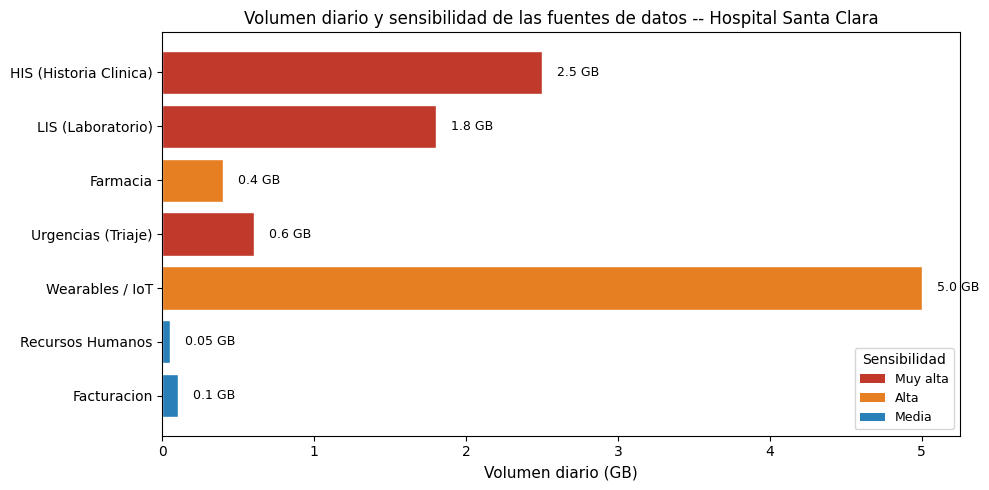

In [3]:
# Visualizacion: volumen diario por fuente, coloreado por sensibilidad
colores_sensibilidad = {
    'Muy alta': '#c0392b',
    'Alta': '#e67e22',
    'Media': '#2980b9'
}

fig, ax = plt.subplots(figsize=(10, 5))

colores = [colores_sensibilidad[s] for s in fuentes['sensibilidad']]
barras = ax.barh(fuentes['fuente'], fuentes['volumen_diario_gb'], color=colores, edgecolor='white')

ax.set_xlabel('Volumen diario (GB)', fontsize=11)
ax.set_title('Volumen diario y sensibilidad de las fuentes de datos -- Hospital Santa Clara',
             fontsize=12)
ax.invert_yaxis()

# Leyenda manual para sensibilidad
from matplotlib.patches import Patch
leyenda = [Patch(facecolor=c, label=s) for s, c in colores_sensibilidad.items()]
ax.legend(handles=leyenda, title='Sensibilidad', loc='lower right', fontsize=9)

# Etiquetas de volumen
for barra, vol in zip(barras, fuentes['volumen_diario_gb']):
    ax.text(barra.get_width() + 0.1, barra.get_y() + barra.get_height()/2,
            f'{vol} GB', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Observa como los wearables/IoT generan el mayor volumen (5 GB/dia) pero con sensibilidad "alta" (no "muy alta"), mientras que HIS y Laboratorio, aunque con menor volumen, contienen datos clinicos de maxima sensibilidad. Esta distincion es clave para el diseno arquitectonico: no todas las fuentes requieren el mismo nivel de cifrado, anonimizacion ni velocidad de acceso.

## 3. Principales tipos de arquitectura de datos

A lo largo de las ultimas decadas, la industria ha desarrollado varios patrones arquitectonicos para organizar los datos. Cada uno responde a necesidades distintas y tiene sus propias fortalezas y limitaciones. Los cuatro mas relevantes en la actualidad son:

**Data Warehouse (Almacen de datos clasico)**
Estructura centralizada y altamente organizada. Los datos se transforman y limpian ANTES de cargarse (esquema predefinido, schema-on-write). Ideal para reporting y analisis estructurado donde las preguntas son conocidas de antemano. Su principal limitacion es la rigidez: anadir nuevas fuentes o cambiar el esquema es costoso.

**Data Lake (Lago de datos)**
Almacen flexible donde los datos se guardan en su formato original (JSON, CSV, imagenes, logs...) y se estructuran solo cuando se consultan (schema-on-read). Permite almacenar grandes volumenes a bajo coste y soporta analisis exploratorio y machine learning. El riesgo principal es convertirse en un "data swamp" (pantano de datos) si no se aplica un minimo de catalogacion y calidad.

**Data Lakehouse**
Patron hibrido que combina la flexibilidad del data lake con las garantias de calidad y transaccionalidad del data warehouse. Tecnologias como Delta Lake, Apache Iceberg o Apache Hudi permiten aplicar esquemas, versionado y transacciones ACID sobre ficheros en un data lake. Es la tendencia dominante en arquitecturas modernas.

**Data Mesh**
Enfoque descentralizado donde cada dominio de negocio (en nuestro caso: urgencias, laboratorio, farmacia...) es responsable de sus propios datos como si fueran un producto. No es una tecnologia sino un modelo organizativo. Requiere madurez cultural y tecnica elevada, pero escala mejor en organizaciones grandes y complejas.

In [4]:
# Tabla comparativa de tipos de arquitectura
comparativa = pd.DataFrame({
    'Criterio': [
        'Estructura',
        'Esquema',
        'Tipos de datos',
        'Caso de uso ideal',
        'Escalabilidad',
        'Complejidad de gestion',
        'Coste relativo',
        'Riesgo principal'
    ],
    'Data Warehouse': [
        'Centralizada, tablas relacionales',
        'Schema-on-write (fijo)',
        'Estructurados',
        'Reporting, BI tradicional',
        'Media (vertical)',
        'Baja-media',
        'Alto (almacenamiento caro)',
        'Rigidez ante cambios'
    ],
    'Data Lake': [
        'Centralizada, ficheros',
        'Schema-on-read (flexible)',
        'Todos (raw)',
        'ML, analisis exploratorio',
        'Alta (horizontal)',
        'Media-alta',
        'Bajo (almacenamiento barato)',
        'Data swamp (pantano)'
    ],
    'Lakehouse': [
        'Hibrida (lake + warehouse)',
        'Schema-on-read + ACID',
        'Todos, con gobernanza',
        'BI + ML en un solo sitio',
        'Alta',
        'Media',
        'Medio',
        'Complejidad tecnologica'
    ],
    'Data Mesh': [
        'Descentralizada (dominios)',
        'Por dominio',
        'Todos',
        'Organizaciones grandes',
        'Muy alta',
        'Alta (organizativa)',
        'Variable',
        'Requiere madurez cultural'
    ]
})

print("=== Comparativa de tipos de arquitectura de datos ===\n")
print(comparativa.to_string(index=False))

=== Comparativa de tipos de arquitectura de datos ===

              Criterio                    Data Warehouse                    Data Lake                  Lakehouse                  Data Mesh
            Estructura Centralizada, tablas relacionales       Centralizada, ficheros Hibrida (lake + warehouse) Descentralizada (dominios)
               Esquema            Schema-on-write (fijo)    Schema-on-read (flexible)      Schema-on-read + ACID                Por dominio
        Tipos de datos                     Estructurados                  Todos (raw)      Todos, con gobernanza                      Todos
     Caso de uso ideal         Reporting, BI tradicional    ML, analisis exploratorio   BI + ML en un solo sitio     Organizaciones grandes
         Escalabilidad                  Media (vertical)            Alta (horizontal)                       Alta                   Muy alta
Complejidad de gestion                        Baja-media                   Media-alta                    

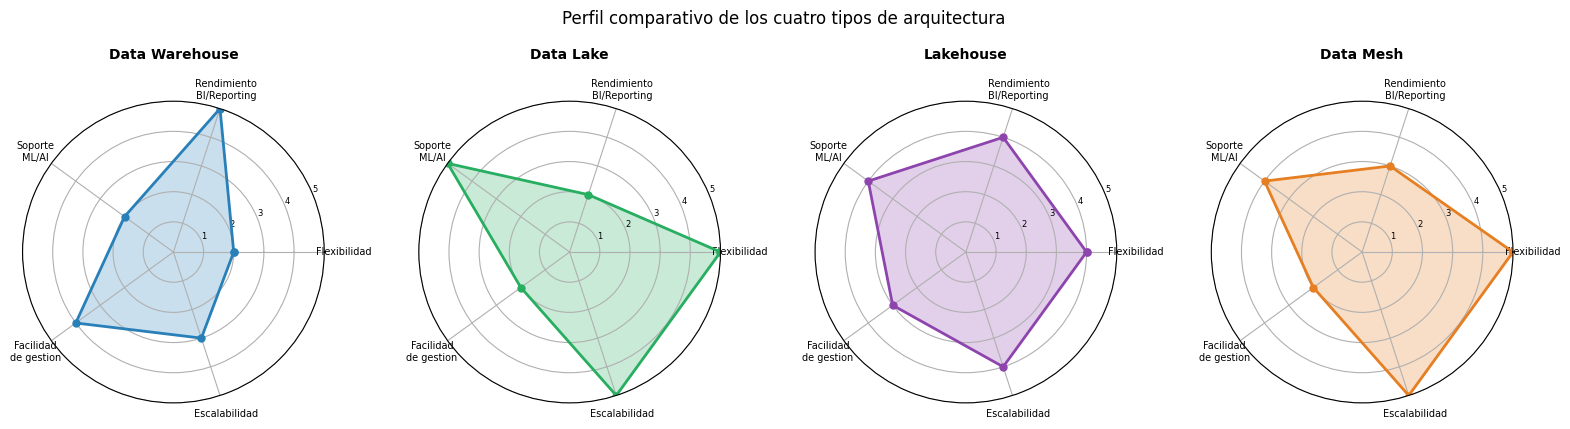

In [5]:
# Visualizacion: radar simplificado de cada arquitectura
# Puntuamos cada tipo en 5 dimensiones (1-5)
dimensiones = ['Flexibilidad', 'Rendimiento\nBI/Reporting', 'Soporte\nML/AI',
               'Facilidad\nde gestion', 'Escalabilidad']
arquitecturas = {
    'Data Warehouse': [2, 5, 2, 4, 3],
    'Data Lake':      [5, 2, 5, 2, 5],
    'Lakehouse':      [4, 4, 4, 3, 4],
    'Data Mesh':      [5, 3, 4, 2, 5]
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw=dict(polar=True))
colores_arq = ['#2980b9', '#27ae60', '#8e44ad', '#e67e22']

angulos = np.linspace(0, 2 * np.pi, len(dimensiones), endpoint=False).tolist()
angulos += angulos[:1]

for ax, (nombre, valores), color in zip(axes, arquitecturas.items(), colores_arq):
    valores_cerrados = valores + valores[:1]
    ax.fill(angulos, valores_cerrados, alpha=0.25, color=color)
    ax.plot(angulos, valores_cerrados, 'o-', color=color, linewidth=2, markersize=5)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(dimensiones, fontsize=7)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=6)
    ax.set_title(nombre, fontsize=10, fontweight='bold', pad=15)

plt.suptitle('Perfil comparativo de los cuatro tipos de arquitectura', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Los graficos radar permiten ver de un vistazo el perfil de cada arquitectura. Observa como no existe una opcion "perfecta": el Data Warehouse destaca en reporting pero es rigido; el Data Lake es muy flexible pero dificil de gobernar; el Lakehouse busca un equilibrio; y el Data Mesh maximiza la escalabilidad organizativa a costa de complejidad.

La eleccion depende siempre del contexto: volumen de datos, variedad de fuentes, madurez del equipo y requisitos de seguridad y cumplimiento normativo.

## 4. Arquitectura por capas: Bronze, Silver y Gold

Independientemente del tipo de arquitectura elegido, un patron que se ha convertido en estandar de facto es la organizacion de los datos en tres capas de calidad creciente:

- **Bronze (Bronce)**: Datos tal cual llegan de la fuente, sin modificar. Se preservan como copia fiel del origen. Pueden contener errores, duplicados, valores nulos y formatos inconsistentes. Es la "caja fuerte" del dato crudo.

- **Silver (Plata)**: Datos limpiados, estandarizados y validados. Se han corregido tipos, eliminado duplicados, tratado nulos y aplicado reglas de negocio basicas (por ejemplo, unificar codigos de diagnostico). Es la capa donde vive la "verdad limpia".

- **Gold (Oro)**: Datos agregados, enriquecidos y listos para consumo directo. Tablas dimensionales para dashboards, metricas precalculadas, datasets preparados para modelos predictivos. Es lo que ve el usuario final.

Vamos a simular este flujo con un ejemplo concreto: registros de urgencias del Hospital Santa Clara.

In [6]:
# === CAPA BRONZE: datos crudos tal cual llegan del sistema de triaje ===
# Simulamos un extracto con errores tipicos de un sistema real

bronze_urgencias = pd.DataFrame({
    'id_paciente': ['P-1001', 'P-1002', 'P-1003', 'P-1001', 'P-1004', 'P-1005', None, 'P-1006'],
    'fecha_ingreso': [
        '2025-03-10 08:15', '2025-03-10 09:30', '10/03/2025 10:00',
        '2025-03-10 08:15', '2025-03-10 11:45', '2025/03/10 12:00',
        '2025-03-10 13:30', '2025-03-10 14:15'
    ],
    'nivel_triaje': [2, 3, 'III', 2, 1, 4, 3, 'dos'],
    'diagnostico': [
        'Infarto agudo miocardio', 'Fractura tibia', 'FRACTURA TIBIA',
        'Infarto agudo miocardio', 'Parada cardiorespiratoria', 'Gripe estacional',
        'Cefalea tensional', 'Dolor abdominal'
    ],
    'tiempo_espera_min': [5, 22, 25, 5, 0, 45, 30, -10],
    'coste_estimado': ['1200.50', '850', None, '1200.50', '3500', '120', '95.00', 'pendiente']
})

print("=== CAPA BRONZE: Datos crudos de urgencias ===\n")
print(bronze_urgencias.to_string(index=False))
print(f"\nRegistros: {len(bronze_urgencias)}")
print(f"Nulos por columna:\n{bronze_urgencias.isnull().sum()}")

=== CAPA BRONZE: Datos crudos de urgencias ===

id_paciente    fecha_ingreso nivel_triaje               diagnostico  tiempo_espera_min coste_estimado
     P-1001 2025-03-10 08:15            2   Infarto agudo miocardio                  5        1200.50
     P-1002 2025-03-10 09:30            3            Fractura tibia                 22            850
     P-1003 10/03/2025 10:00          III            FRACTURA TIBIA                 25           None
     P-1001 2025-03-10 08:15            2   Infarto agudo miocardio                  5        1200.50
     P-1004 2025-03-10 11:45            1 Parada cardiorespiratoria                  0           3500
     P-1005 2025/03/10 12:00            4          Gripe estacional                 45            120
       None 2025-03-10 13:30            3         Cefalea tensional                 30          95.00
     P-1006 2025-03-10 14:15          dos           Dolor abdominal                -10      pendiente

Registros: 8
Nulos por columna:
i

Observa los problemas tipicos que aparecen en datos brutos reales:

- **Duplicados**: el paciente P-1001 aparece dos veces con los mismos datos (posible doble registro).
- **Formatos de fecha inconsistentes**: "2025-03-10 08:15" vs "10/03/2025 10:00" vs "2025/03/10 12:00".
- **Codificacion mixta del triaje**: numeros (2, 3, 1), numeros romanos ("III"), texto ("dos").
- **Diagnosticos sin normalizar**: "Fractura tibia" y "FRACTURA TIBIA" son el mismo diagnostico.
- **Valores imposibles**: tiempo de espera negativo (-10 minutos).
- **Tipos incorrectos**: coste como texto ("pendiente", strings en vez de float).
- **Nulos**: id_paciente y coste con valores faltantes.

Ahora vamos a limpiar estos datos para llevarlos a la capa Silver:

In [8]:
# === CAPA SILVER: datos limpios y estandarizados ===

silver_urgencias = bronze_urgencias.copy()

# 1. Eliminar duplicados exactos
silver_urgencias = silver_urgencias.drop_duplicates()

# 2. Eliminar registros sin identificador de paciente
silver_urgencias = silver_urgencias.dropna(subset=['id_paciente'])

# 3. Estandarizar fechas a formato ISO
def estandarizar_fecha(fecha_str):
    # \"\"\"Intenta parsear distintos formatos de fecha al formato estandar.\"\"\"
    for fmt in ['%Y-%m-%d %H:%M', '%d/%m/%Y %H:%M', '%Y/%m/%d %H:%M']:
        try:
            return pd.to_datetime(fecha_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT

silver_urgencias['fecha_ingreso'] = silver_urgencias['fecha_ingreso'].apply(estandarizar_fecha)

# 4. Normalizar nivel de triaje a entero
mapa_triaje = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5,
               'uno': 1, 'dos': 2, 'tres': 3, 'cuatro': 4, 'cinco': 5}

def normalizar_triaje(valor):
    # \"\"\"Convierte cualquier representacion del triaje a entero 1-5.\"\"\"
    if pd.isna(valor):
        return None
    if isinstance(valor, (int, float)):
        return int(valor)
    return mapa_triaje.get(str(valor).strip(), None)

silver_urgencias['nivel_triaje'] = silver_urgencias['nivel_triaje'].apply(normalizar_triaje)

# 5. Normalizar diagnosticos (minusculas, sin espacios extra)
silver_urgencias['diagnostico'] = (silver_urgencias['diagnostico']
                                    .str.strip()
                                    .str.lower()
                                    .str.title())

# 6. Corregir valores imposibles en tiempo de espera
silver_urgencias.loc[silver_urgencias['tiempo_espera_min'] < 0, 'tiempo_espera_min'] = None

# 7. Convertir coste a numerico
silver_urgencias['coste_estimado'] = pd.to_numeric(silver_urgencias['coste_estimado'], errors='coerce')

# Resetear indice
silver_urgencias = silver_urgencias.reset_index(drop=True)

print("=== CAPA SILVER: Datos limpios y estandarizados ===\n")
print(silver_urgencias.to_string(index=False))
print(f"\nRegistros: {len(silver_urgencias)} (de {len(bronze_urgencias)} originales)")
print(f"Nulos por columna:\n{silver_urgencias.isnull().sum()}")

=== CAPA SILVER: Datos limpios y estandarizados ===

id_paciente       fecha_ingreso  nivel_triaje               diagnostico  tiempo_espera_min  coste_estimado
     P-1001 2025-03-10 08:15:00             2   Infarto Agudo Miocardio                5.0          1200.5
     P-1002 2025-03-10 09:30:00             3            Fractura Tibia               22.0           850.0
     P-1003 2025-03-10 10:00:00             3            Fractura Tibia               25.0             NaN
     P-1004 2025-03-10 11:45:00             1 Parada Cardiorespiratoria                0.0          3500.0
     P-1005 2025-03-10 12:00:00             4          Gripe Estacional               45.0           120.0
     P-1006 2025-03-10 14:15:00             2           Dolor Abdominal                NaN             NaN

Registros: 6 (de 8 originales)
Nulos por columna:
id_paciente          0
fecha_ingreso        0
nivel_triaje         0
diagnostico          0
tiempo_espera_min    1
coste_estimado       2
dtype: in

En la capa Silver hemos pasado de 8 registros sucios a 6 registros limpios y coherentes. Los nulos restantes (1 en tiempo_espera_min, 1 en coste_estimado) representan informacion genuinamente desconocida, no errores de formato. Ahora estos datos son fiables para analisis.

El ultimo paso es agregar y enriquecer para la capa Gold, donde los datos estan listos para consumo directo por parte de dashboards o modelos:

In [9]:
# === CAPA GOLD: datos agregados y listos para consumo ===

# Ejemplo 1: Metricas operativas por nivel de triaje (para dashboard de urgencias)
gold_metricas_triaje = (silver_urgencias
    .groupby('nivel_triaje')
    .agg(
        num_pacientes=('id_paciente', 'count'),
        tiempo_espera_medio=('tiempo_espera_min', 'mean'),
        coste_medio=('coste_estimado', 'mean')
    )
    .round(1)
    .reset_index()
)
gold_metricas_triaje.columns = [
    'Nivel Triaje', 'Num. Pacientes', 'Espera Media (min)', 'Coste Medio (EUR)'
]

print("=== CAPA GOLD: Metricas por nivel de triaje ===\n")
print(gold_metricas_triaje.to_string(index=False))

# Ejemplo 2: Resumen ejecutivo diario (para informe de direccion)
resumen_diario = {
    'Fecha': '2025-03-10',
    'Total pacientes': len(silver_urgencias),
    'Pacientes criticos (triaje 1-2)': len(silver_urgencias[silver_urgencias['nivel_triaje'] <= 2]),
    'Tiempo espera medio (min)': round(silver_urgencias['tiempo_espera_min'].mean(), 1),
    'Coste total estimado (EUR)': round(silver_urgencias['coste_estimado'].sum(), 2)
}

print("\n=== CAPA GOLD: Resumen ejecutivo diario ===\n")
for clave, valor in resumen_diario.items():
    print(f"  {clave}: {valor}")

=== CAPA GOLD: Metricas por nivel de triaje ===

 Nivel Triaje  Num. Pacientes  Espera Media (min)  Coste Medio (EUR)
            1               1                 0.0             3500.0
            2               2                 5.0             1200.5
            3               2                23.5              850.0
            4               1                45.0              120.0

=== CAPA GOLD: Resumen ejecutivo diario ===

  Fecha: 2025-03-10
  Total pacientes: 6
  Pacientes criticos (triaje 1-2): 3
  Tiempo espera medio (min): 19.4
  Coste total estimado (EUR): 5670.5


La capa Gold contiene exactamente lo que necesita cada consumidor: el dashboard de urgencias recibe metricas por nivel de triaje; el informe de direccion recibe un resumen ejecutivo diario. Ningun consumidor necesita saber como eran los datos originales en bruto -- la arquitectura por capas encapsula esa complejidad.

Este patron Bronze-Silver-Gold es aplicable a cualquier tipo de arquitectura (warehouse, lake, lakehouse) y constituye una buena practica independientemente de la tecnologia subyacente.

## 5. Cuando usar que: matriz de decision arquitectonica

En la practica profesional, la eleccion de arquitectura rara vez es evidente. Depende de multiples factores que se deben evaluar conjuntamente. Los cuatro criterios mas relevantes, a menudo llamados las "4V" adaptadas, son:

- **Volumen**: Cantidad de datos generados y almacenados.
- **Variedad**: Diversidad de formatos y fuentes.
- **Velocidad**: Requisitos de latencia (tiempo real vs. por lotes).
- **Sensibilidad**: Nivel de proteccion y cumplimiento normativo requerido.

Vamos a construir una funcion que, dados estos parametros, sugiera la arquitectura mas adecuada. No es un algoritmo definitivo -- en la realidad intervienen muchos mas factores -- pero ilustra el tipo de razonamiento que un arquitecto de datos debe realizar:

In [ ]:
def recomendar_arquitectura(volumen, variedad, velocidad, sensibilidad):
    \"\"\"
    Recomienda una arquitectura de datos basandose en cuatro criterios.

    Parametros (escala 1-5):
        volumen:      1=muy bajo, 5=muy alto
        variedad:     1=solo estructurados, 5=muy heterogeneos
        velocidad:    1=lotes semanales, 5=tiempo real
        sensibilidad: 1=datos publicos, 5=datos clinicos/personales

    Retorna: nombre de la arquitectura recomendada y justificacion.
    \"\"\"
    puntuaciones = {}

    # Data Warehouse: ideal para baja variedad, alta sensibilidad, volumen moderado
    puntuaciones['Data Warehouse'] = (
        (5 - variedad) * 2 +
        sensibilidad * 1.5 +
        (5 - volumen) * 1 +
        (5 - velocidad) * 1
    )

    # Data Lake: ideal para alto volumen, alta variedad, baja sensibilidad
    puntuaciones['Data Lake'] = (
        variedad * 2 +
        volumen * 1.5 +
        velocidad * 1 +
        (5 - sensibilidad) * 1.5
    )

    # Lakehouse: equilibrio general, bueno cuando hay mix de necesidades
    puntuaciones['Data Lakehouse'] = (
        variedad * 1.5 +
        volumen * 1 +
        velocidad * 1 +
        sensibilidad * 1 +
        3  # bonus por versatilidad
    )

    # Data Mesh: ideal para organizaciones grandes con multiples dominios
    bonus_mesh = 2 if volumen >= 4 and variedad >= 4 else 0
    puntuaciones['Data Mesh'] = (
        variedad * 1.5 +
        volumen * 1.5 +
        velocidad * 0.5 +
        (5 - sensibilidad) * 0.5 +
        bonus_mesh
    )

    # Seleccionar la arquitectura con mayor puntuacion
    mejor = max(puntuaciones, key=puntuaciones.get)

    print(f"  Parametros: Volumen={volumen}, Variedad={variedad}, "
          f"Velocidad={velocidad}, Sensibilidad={sensibilidad}")
    print(f"  Puntuaciones: {', '.join(f'{k}={v:.1f}' for k, v in puntuaciones.items())}")
    print(f"  >>> Recomendacion: {mejor}\n")

    return mejor


# Escenario 1: Hospital General Santa Clara
print("=== Escenario 1: Hospital General Santa Clara ===")
print("  (alto volumen IoT, variedad media, necesita tiempo real, datos muy sensibles)")
recomendar_arquitectura(volumen=4, variedad=3, velocidad=4, sensibilidad=5)

# Escenario 2: Clinica dental pequena
print("=== Escenario 2: Clinica dental con 3 consultorios ===")
print("  (bajo volumen, solo datos estructurados, lotes diarios, sensibilidad alta)")
recomendar_arquitectura(volumen=1, variedad=1, velocidad=1, sensibilidad=4)

# Escenario 3: Centro de investigacion biomedica
print("=== Escenario 3: Centro de investigacion biomedica ===")
print("  (alto volumen, datos muy variados, analisis en lotes, sensibilidad media)")
recomendar_arquitectura(volumen=5, variedad=5, velocidad=2, sensibilidad=3)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2520641712.py, line 4)

: 

Observa como la funcion asigna mayor peso a los factores mas discriminantes para cada tipo de arquitectura. Para el hospital, con datos sensibles y necesidad de tiempo real, el Lakehouse ofrece el mejor equilibrio. La clinica pequena no necesita la complejidad de un lake y le basta un warehouse clasico. El centro de investigacion, con datos masivos y muy variados, se beneficia de la flexibilidad de un Data Lake.

En la realidad, esta decision se complementa con otros factores como el presupuesto disponible, la madurez tecnica del equipo, los requisitos regulatorios especificos y la estrategia tecnologica de la organizacion.

## 6. Reflexion y conexion con la siguiente sesion

En esta sesion hemos establecido el vocabulario y los marcos conceptuales fundamentales de la arquitectura de datos. Hemos visto que no existe una solucion universal: cada organizacion debe evaluar sus necesidades de volumen, variedad, velocidad y sensibilidad para elegir el patron mas adecuado.

**Preguntas para discusion en grupo:**

1. Si el Hospital Santa Clara decide incorporar telemedicina con dispositivos IoT domiciliarios, como cambiaria el perfil de sus datos? Que tipo de arquitectura soportaria mejor ese cambio?

2. En la sesion de etica discutimos los sesgos en modelos de IA. Como puede la arquitectura de datos (concretamente, la capa Silver) contribuir a detectar o prevenir esos sesgos antes de que lleguen a un modelo?

3. Pensad en una empresa u organizacion que conozcais (vuestro lugar de trabajo, un caso de estudio, etc.). Que tipo de arquitectura creeis que utiliza? Por que?

**Conexion con la siguiente sesion:**
En la proxima clase abordaremos el concepto de Data Hub, la integracion de datos entre sistemas, y como el gobierno del dato se asienta sobre la arquitectura que hemos definido hoy. La arquitectura nos dice "como se organiza"; el gobierno nos dira "quien decide que y con que reglas".